In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/pedidos.csv")

df.head()

,pedido_id,data_pedido,horario_pedido,restaurante,categoria,cidade,valor_pedido,tempo_entrega_min,avaliacao,metodo_pagamento,status
0,1,2026-06-13,11:01,Cantinho da Massa,Massas,Eusébio,55.71,62.0,1.0,Cartão de crédito,Entregue
1,2,2026-01-09,10:05,Sushi Fortaleza,Sushi,Eusébio,100.86,16.0,5.0,Cartão de débito,Entregue
2,3,2026-06-29,18:26,Sushi Fortaleza,Sushi,Maracanaú,114.28,66.0,1.0,Cartão de débito,Entregue
3,4,2026-03-29,14:09,Sushi Fortaleza,Sushi,Caucaia,36.35,39.0,1.0,Pix,Entregue
4,5,2026-06-04,14:51,Sabor Nordestino,Brasileira,Maracanaú,105.80,39.0,1.0,Pix,Entregue


In [3]:
df.shape

(5003, 11)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5003 entries, 0 to 5002
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pedido_id          5003 non-null   int64  
 1   data_pedido        5003 non-null   str    
 2   horario_pedido     5003 non-null   str    
 3   restaurante        5003 non-null   str    
 4   categoria          5003 non-null   str    
 5   cidade             5002 non-null   str    
 6   valor_pedido       5003 non-null   float64
 7   tempo_entrega_min  5002 non-null   float64
 8   avaliacao          5002 non-null   float64
 9   metodo_pagamento   5003 non-null   str    
 10  status             5003 non-null   str    
dtypes: float64(3), int64(1), str(7)
memory usage: 754.3 KB


In [5]:
df.isnull().sum()

pedido_id            0
data_pedido          0
horario_pedido       0
restaurante          0
categoria            0
cidade               1
valor_pedido         0
tempo_entrega_min    1
avaliacao            1
metodo_pagamento     0
status               0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(3)

In [7]:
df[df.isnull().any(axis=1)]

,pedido_id,data_pedido,horario_pedido,restaurante,categoria,cidade,valor_pedido,tempo_entrega_min,avaliacao,metodo_pagamento,status
100,101,2026-02-02,18:37,Churrasco & Cia,Churrasco,Fortaleza,159.87,43.0,NaN,Dinheiro,Entregue
250,251,2026-05-01,22:53,Churrasco & Cia,Churrasco,Eusébio,79.31,NaN,1.0,Cartão de débito,Entregue
400,401,2026-04-16,10:55,Burger House,Hambúrguer,NaN,178.78,36.0,4.0,Dinheiro,Entregue


In [8]:
df[df.duplicated(keep=False)].sort_values("pedido_id")

,pedido_id,data_pedido,horario_pedido,restaurante,categoria,cidade,valor_pedido,tempo_entrega_min,avaliacao,metodo_pagamento,status
50,51,2026-01-19,17:26,Sushi Fortaleza,Sushi,Maracanaú,99.10,30.0,2.0,Cartão de crédito,Entregue
5000,51,2026-01-19,17:26,Sushi Fortaleza,Sushi,Maracanaú,99.10,30.0,2.0,Cartão de crédito,Entregue
150,151,2026-03-15,11:41,Pizza Express,Pizza,Maracanaú,94.03,50.0,1.0,Dinheiro,Entregue
5001,151,2026-03-15,11:41,Pizza Express,Pizza,Maracanaú,94.03,50.0,1.0,Dinheiro,Entregue
300,301,2026-05-17,14:38,Burger House,Hambúrguer,Caucaia,176.64,33.0,3.0,Pix,Cancelado
5002,301,2026-05-17,14:38,Burger House,Hambúrguer,Caucaia,176.64,33.0,3.0,Pix,Cancelado


In [9]:
duplicados = df[df.duplicated(keep=False)]

duplicados.sort_values(
    ["data_pedido", "horario_pedido", "restaurante"]
)

,pedido_id,data_pedido,horario_pedido,restaurante,categoria,cidade,valor_pedido,tempo_entrega_min,avaliacao,metodo_pagamento,status
50,51,2026-01-19,17:26,Sushi Fortaleza,Sushi,Maracanaú,99.10,30.0,2.0,Cartão de crédito,Entregue
5000,51,2026-01-19,17:26,Sushi Fortaleza,Sushi,Maracanaú,99.10,30.0,2.0,Cartão de crédito,Entregue
150,151,2026-03-15,11:41,Pizza Express,Pizza,Maracanaú,94.03,50.0,1.0,Dinheiro,Entregue
5001,151,2026-03-15,11:41,Pizza Express,Pizza,Maracanaú,94.03,50.0,1.0,Dinheiro,Entregue
300,301,2026-05-17,14:38,Burger House,Hambúrguer,Caucaia,176.64,33.0,3.0,Pix,Cancelado
5002,301,2026-05-17,14:38,Burger House,Hambúrguer,Caucaia,176.64,33.0,3.0,Pix,Cancelado


In [10]:
df = df.drop_duplicates(
    subset=[
        "data_pedido",
        "horario_pedido",
        "restaurante",
        "categoria",
        "cidade",
        "valor_pedido",
        "tempo_entrega_min",
        "avaliacao",
        "metodo_pagamento",
        "status",
    ],
    keep="first",
)

In [11]:
df.shape

(5000, 11)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["tempo_entrega_min"].describe()

count    4999.000000
mean       42.531506
std        16.056939
min        15.000000
25%        29.000000
50%        43.000000
75%        57.000000
max        70.000000
Name: tempo_entrega_min, dtype: float64

In [14]:
df["avaliacao"].describe()

count    4999.000000
mean        2.992999
std         1.423714
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: avaliacao, dtype: float64

In [15]:
df["cidade"].value_counts()

cidade
Maracanaú    1300
Caucaia      1263
Fortaleza    1234
Eusébio      1202
Name: count, dtype: int64

In [16]:
df["categoria"].value_counts()

categoria
Hambúrguer    656
Saudável      654
Brasileira    651
Massas        633
Churrasco     620
Pizza         610
Açaí          605
Sushi         571
Name: count, dtype: int64

In [17]:
df["categoria"].value_counts(normalize=True) * 100

categoria
Hambúrguer    13.12
Saudável      13.08
Brasileira    13.02
Massas        12.66
Churrasco     12.40
Pizza         12.20
Açaí          12.10
Sushi         11.42
Name: proportion, dtype: float64

In [18]:
df["valor_pedido"].describe()

count    5000.000000
mean      100.571488
std        46.446242
min        20.080000
25%        59.490000
50%       100.870000
75%       140.347500
max       179.900000
Name: valor_pedido, dtype: float64

In [19]:
df["valor_pedido"].sum()

np.float64(502857.44)

In [20]:
faturamento_categoria = (
    df.groupby("categoria")["valor_pedido"]
    .sum()
    .sort_values(ascending=False)
)

faturamento_categoria

categoria
Hambúrguer    66968.98
Brasileira    65424.36
Saudável      65036.96
Pizza         63545.84
Churrasco     62790.57
Massas        62337.92
Açaí          58655.31
Sushi         58097.50
Name: valor_pedido, dtype: float64

In [21]:
ticket_medio_categoria = (
    df.groupby("categoria")["valor_pedido"]
    .mean()
    .sort_values(ascending=False)
)

ticket_medio_categoria

categoria
Pizza         104.173508
Hambúrguer    102.086860
Sushi         101.746935
Churrasco     101.275113
Brasileira    100.498249
Saudável       99.444893
Massas         98.480126
Açaí           96.950926
Name: valor_pedido, dtype: float64

In [22]:
avaliacao_categoria = (
    df.groupby("categoria")["avaliacao"]
    .mean()
    .sort_values(ascending=False)
)

avaliacao_categoria

categoria
Churrasco     3.054927
Brasileira    3.044547
Pizza         3.042623
Saudável      3.036697
Massas        3.033175
Sushi         2.961471
Hambúrguer    2.887195
Açaí          2.879339
Name: avaliacao, dtype: float64

In [23]:
pedidos_cidade = (
    df["cidade"]
    .value_counts()
    .sort_values(ascending=False)
)

pedidos_cidade

cidade
Maracanaú    1300
Caucaia      1263
Fortaleza    1234
Eusébio      1202
Name: count, dtype: int64

In [24]:
faturamento_cidade = (
    df.groupby("cidade")["valor_pedido"]
    .sum()
    .sort_values(ascending=False)
)

faturamento_cidade

cidade
Maracanaú    129394.07
Caucaia      127516.41
Fortaleza    124313.04
Eusébio      121455.14
Name: valor_pedido, dtype: float64

In [25]:
tempo_entrega_cidade = (
    df.groupby("cidade")["tempo_entrega_min"]
    .mean()
    .sort_values(ascending=False)
)

tempo_entrega_cidade

cidade
Maracanaú    42.804615
Caucaia      42.661916
Eusébio      42.383847
Fortaleza    42.259319
Name: tempo_entrega_min, dtype: float64

In [26]:
df["faixa_tempo"] = pd.cut(
    df["tempo_entrega_min"],
    bins=[0, 30, 45, 60, 75],
    labels=["Até 30 min", "31–45 min", "46–60 min", "Mais de 60 min"]
)

df.groupby("faixa_tempo", observed=True)["avaliacao"].mean()

faixa_tempo
Até 30 min        3.002076
31–45 min         2.985507
46–60 min         2.996345
Mais de 60 min    2.986270
Name: avaliacao, dtype: float64

In [27]:
df["faixa_tempo"].value_counts().sort_index()

faixa_tempo
Até 30 min        1445
31–45 min         1312
46–60 min         1368
Mais de 60 min     874
Name: count, dtype: int64

In [28]:
df[["tempo_entrega_min", "avaliacao"]].corr()

,tempo_entrega_min,avaliacao
tempo_entrega_min,1.000000,0.000915
avaliacao,0.000915,1.000000


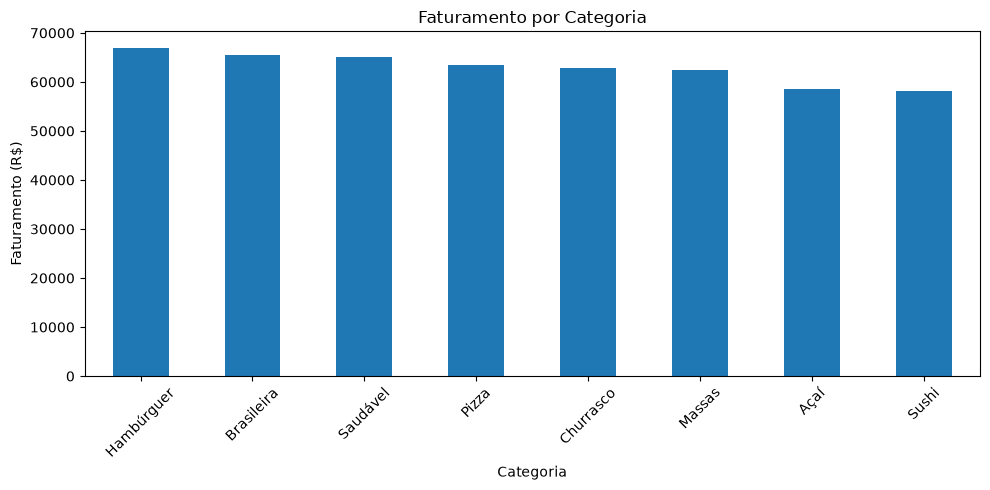

In [29]:
import matplotlib.pyplot as plt

faturamento_categoria.plot(
    kind="bar",
    figsize=(10, 5),
    title="Faturamento por Categoria"
)

plt.xlabel("Categoria")
plt.ylabel("Faturamento (R$)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

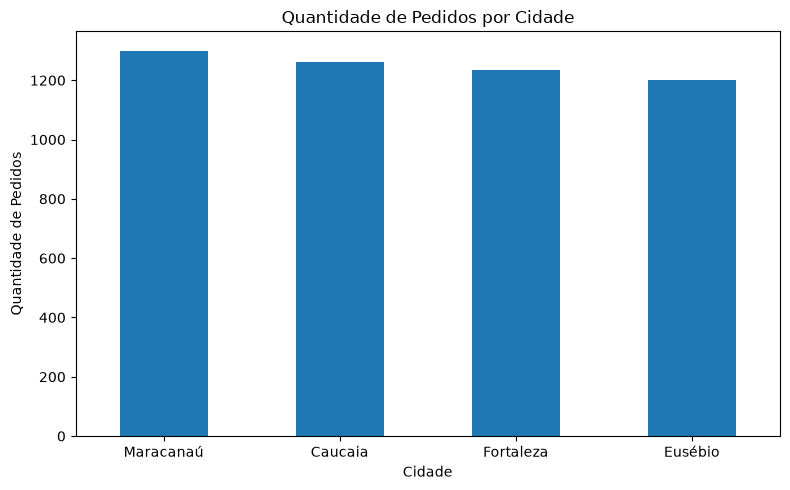

In [30]:
pedidos_cidade.plot(
    kind="bar",
    figsize=(8, 5),
    title="Quantidade de Pedidos por Cidade"
)

plt.xlabel("Cidade")
plt.ylabel("Quantidade de Pedidos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

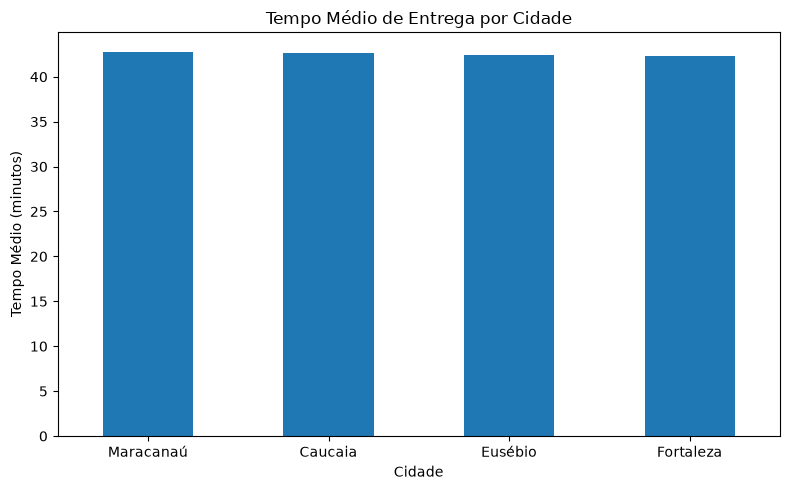

In [31]:
tempo_entrega_cidade.plot(
    kind="bar",
    figsize=(8, 5),
    title="Tempo Médio de Entrega por Cidade"
)

plt.xlabel("Cidade")
plt.ylabel("Tempo Médio (minutos)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

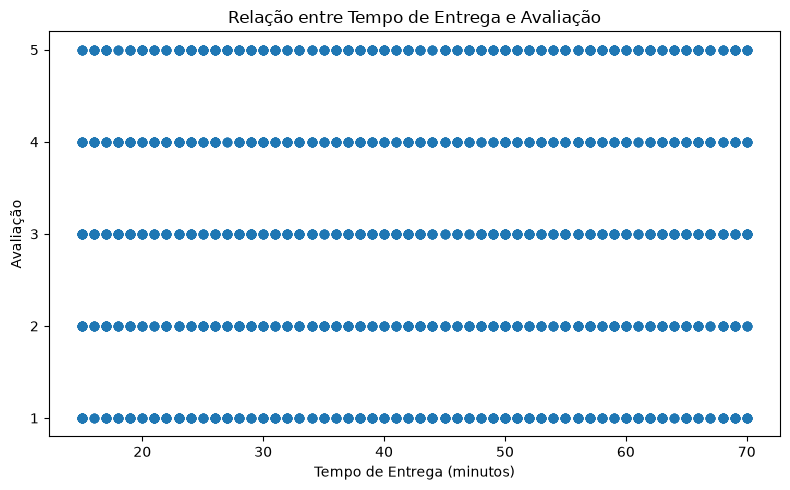

In [32]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["tempo_entrega_min"],
    df["avaliacao"],
    alpha=0.5
)

plt.title("Relação entre Tempo de Entrega e Avaliação")
plt.xlabel("Tempo de Entrega (minutos)")
plt.ylabel("Avaliação")
plt.yticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.show()

In [33]:
correlacao = df["tempo_entrega_min"].corr(df["avaliacao"])

print(f"Correlação entre tempo de entrega e avaliação: {correlacao:.2f}")

Correlação entre tempo de entrega e avaliação: 0.00


In [34]:
df["data_pedido"] = pd.to_datetime(df["data_pedido"])

In [35]:
df.dtypes

pedido_id                     int64
data_pedido          datetime64[us]
horario_pedido                  str
restaurante                     str
categoria                       str
cidade                          str
valor_pedido                float64
tempo_entrega_min           float64
avaliacao                   float64
metodo_pagamento                str
status                          str
faixa_tempo                category
dtype: object

In [36]:
df["dia_semana"] = df["data_pedido"].dt.day_name()

In [37]:
df["dia_semana"].value_counts()

dia_semana
Thursday     752
Saturday     749
Friday       727
Monday       724
Tuesday      711
Sunday       670
Wednesday    667
Name: count, dtype: int64

In [38]:
df["mes"] = df["data_pedido"].dt.month

In [39]:
df["mes"].value_counts().sort_index()

mes
1    854
2    745
3    822
4    862
5    859
6    858
Name: count, dtype: int64

In [40]:
df["hora_pedido"] = df["horario_pedido"].str[:2].astype(int)

In [41]:
df["hora_pedido"].value_counts().sort_index()

hora_pedido
10    357
11    331
12    376
13    323
14    350
15    380
16    386
17    388
18    338
19    344
20    371
21    347
22    356
23    353
Name: count, dtype: int64

In [42]:
pedidos_por_hora = (
    df["hora_pedido"]
    .value_counts()
    .sort_index()
)

pedidos_por_hora

hora_pedido
10    357
11    331
12    376
13    323
14    350
15    380
16    386
17    388
18    338
19    344
20    371
21    347
22    356
23    353
Name: count, dtype: int64

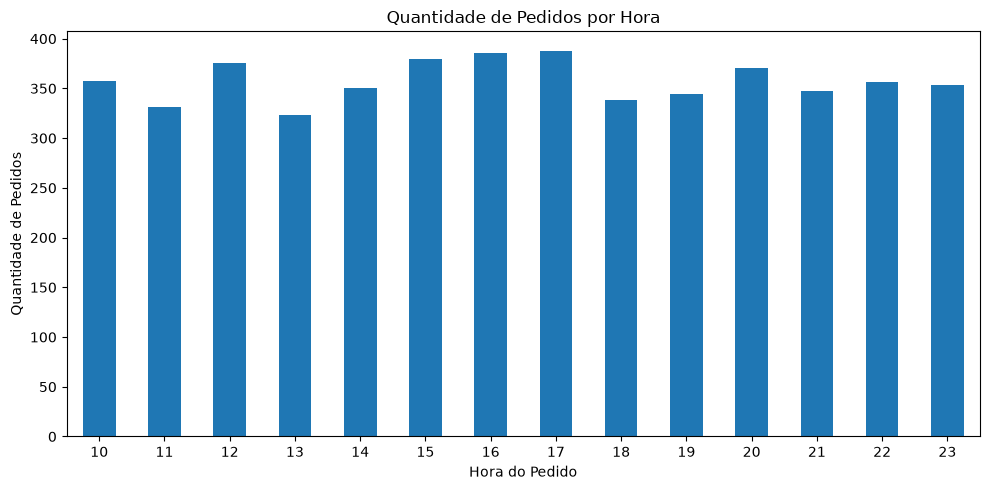

In [43]:
pedidos_por_hora.plot(
    kind="bar",
    figsize=(10, 5),
    title="Quantidade de Pedidos por Hora"
)

plt.xlabel("Hora do Pedido")
plt.ylabel("Quantidade de Pedidos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [44]:
ordem_dias = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

pedidos_por_dia = (
    df["dia_semana"]
    .value_counts()
    .reindex(ordem_dias)
)

pedidos_por_dia

dia_semana
Monday       724
Tuesday      711
Wednesday    667
Thursday     752
Friday       727
Saturday     749
Sunday       670
Name: count, dtype: int64

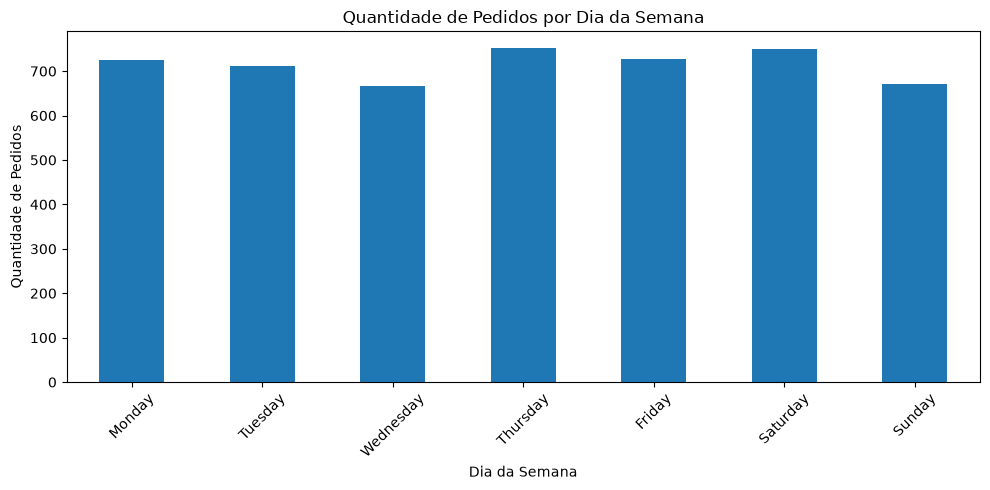

In [45]:
pedidos_por_dia.plot(
    kind="bar",
    figsize=(10, 5),
    title="Quantidade de Pedidos por Dia da Semana"
)

plt.xlabel("Dia da Semana")
plt.ylabel("Quantidade de Pedidos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [46]:
faturamento_por_hora = (
    df.groupby("hora_pedido")["valor_pedido"]
    .sum()
    .sort_index()
)

faturamento_por_hora

hora_pedido
10    35588.52
11    33004.81
12    37976.76
13    32931.51
14    36062.38
15    36529.95
16    37202.47
17    38643.51
18    34401.70
19    34552.51
20    38680.96
21    37387.77
22    35175.30
23    34719.29
Name: valor_pedido, dtype: float64

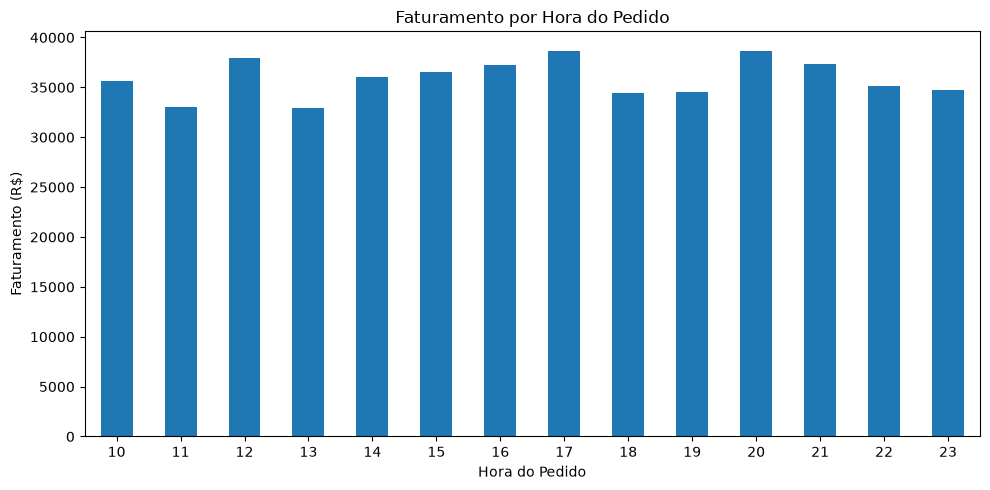

In [47]:
faturamento_por_hora.plot(
    kind="bar",
    figsize=(10, 5),
    title="Faturamento por Hora do Pedido"
)

plt.xlabel("Hora do Pedido")
plt.ylabel("Faturamento (R$)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [48]:
ticket_medio_cidade = (
    df.groupby("cidade")["valor_pedido"]
    .mean()
    .sort_values(ascending=False)
)

ticket_medio_cidade

cidade
Eusébio      101.044210
Caucaia      100.963112
Fortaleza    100.739903
Maracanaú     99.533900
Name: valor_pedido, dtype: float64

In [49]:
pd.DataFrame({
    "Pedidos": pedidos_cidade,
    "Faturamento": faturamento_cidade,
    "Ticket Médio": ticket_medio_cidade
})

,Pedidos,Faturamento,Ticket Médio
cidade,,,
Caucaia,1263,127516.41,100.963112
Eusébio,1202,121455.14,101.044210
Fortaleza,1234,124313.04,100.739903
Maracanaú,1300,129394.07,99.533900


In [50]:
indicadores = {
    "Total de pedidos": len(df),
    "Faturamento total": df["valor_pedido"].sum(),
    "Ticket médio": df["valor_pedido"].mean(),
    "Tempo médio de entrega": df["tempo_entrega_min"].mean(),
    "Avaliação média": df["avaliacao"].mean(),
    "Taxa de cancelamento": (df["status"] == "Cancelado").mean() * 100
}

indicadores

{'Total de pedidos': 5000,
 'Faturamento total': np.float64(502857.44),
 'Ticket médio': np.float64(100.571488),
 'Tempo médio de entrega': np.float64(42.53150630126025),
 'Avaliação média': np.float64(2.992998599719944),
 'Taxa de cancelamento': np.float64(4.96)}

In [51]:
kpis = pd.DataFrame(
    list(indicadores.items()),
    columns=["Indicador", "Valor"]
)

kpis

,Indicador,Valor
0,Total de pedidos,5000.000000
1,Faturamento total,502857.440000
2,Ticket médio,100.571488
3,Tempo médio de entrega,42.531506
4,Avaliação média,2.992999
5,Taxa de cancelamento,4.960000


In [53]:
from sqlalchemy import create_engine

In [54]:
import os

from dotenv import load_dotenv
from sqlalchemy import create_engine, text

ModuleNotFoundError: No module named 'dotenv'

In [1]:
print("Kernel funcionando!")

Kernel funcionando!


In [2]:
import os

from dotenv import load_dotenv
from sqlalchemy import create_engine, text

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


In [3]:
load_dotenv()

db_user = os.getenv("DB_USER")
db_password = os.getenv("DB_PASSWORD")
db_host = os.getenv("DB_HOST")
db_port = os.getenv("DB_PORT")
db_name = os.getenv("DB_NAME")

print("Usuário:", db_user)
print("Host:", db_host)
print("Porta:", db_port)
print("Banco:", db_name)

Usuário: postgres
Host: localhost
Porta: 5432
Banco: foodinsights


In [4]:
engine = create_engine(
    f"postgresql+psycopg2://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}"
)

with engine.connect() as conexao:
    resultado = conexao.execute(text("SELECT version();"))
    print(resultado.fetchone())

('PostgreSQL 18.6 on x86_64-windows, compiled by msvc-19.44.35228, 64-bit',)


In [5]:
df = pd.read_csv("../data/pedidos.csv")

df.head()

NameError: name 'pd' is not defined

In [6]:
import os
import pandas as pd

from dotenv import load_dotenv
from sqlalchemy import create_engine, text

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


In [7]:
load_dotenv()

db_user = os.getenv("DB_USER")
db_password = os.getenv("DB_PASSWORD")
db_host = os.getenv("DB_HOST")
db_port = os.getenv("DB_PORT")
db_name = os.getenv("DB_NAME")

print("Usuário:", db_user)
print("Host:", db_host)
print("Porta:", db_port)
print("Banco:", db_name)

Usuário: postgres
Host: localhost
Porta: 5432
Banco: foodinsights


In [8]:
engine = create_engine(
    f"postgresql+psycopg2://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}"
)

with engine.connect() as conexao:
    resultado = conexao.execute(text("SELECT version();"))
    print(resultado.fetchone())

('PostgreSQL 18.6 on x86_64-windows, compiled by msvc-19.44.35228, 64-bit',)


In [9]:
df = pd.read_csv("../data/pedidos.csv")

print(f"Total de registros: {len(df)}")
df.head()

Total de registros: 5003


,pedido_id,data_pedido,horario_pedido,restaurante,categoria,cidade,valor_pedido,tempo_entrega_min,avaliacao,metodo_pagamento,status
0,1,2026-06-13,11:01,Cantinho da Massa,Massas,Eusébio,55.71,62.0,1.0,Cartão de crédito,Entregue
1,2,2026-01-09,10:05,Sushi Fortaleza,Sushi,Eusébio,100.86,16.0,5.0,Cartão de débito,Entregue
2,3,2026-06-29,18:26,Sushi Fortaleza,Sushi,Maracanaú,114.28,66.0,1.0,Cartão de débito,Entregue
3,4,2026-03-29,14:09,Sushi Fortaleza,Sushi,Caucaia,36.35,39.0,1.0,Pix,Entregue
4,5,2026-06-04,14:51,Sabor Nordestino,Brasileira,Maracanaú,105.80,39.0,1.0,Pix,Entregue


In [10]:
df.to_sql(
    "pedidos",
    engine,
    if_exists="replace",
    index=False
)

print("Tabela 'pedidos' criada com sucesso!")

Tabela 'pedidos' criada com sucesso!


In [11]:
consulta = pd.read_sql(
    "SELECT * FROM pedidos LIMIT 5;",
    engine
)

consulta

,pedido_id,data_pedido,horario_pedido,restaurante,categoria,cidade,valor_pedido,tempo_entrega_min,avaliacao,metodo_pagamento,status
0,1,2026-06-13,11:01,Cantinho da Massa,Massas,Eusébio,55.71,62.0,1.0,Cartão de crédito,Entregue
1,2,2026-01-09,10:05,Sushi Fortaleza,Sushi,Eusébio,100.86,16.0,5.0,Cartão de débito,Entregue
2,3,2026-06-29,18:26,Sushi Fortaleza,Sushi,Maracanaú,114.28,66.0,1.0,Cartão de débito,Entregue
3,4,2026-03-29,14:09,Sushi Fortaleza,Sushi,Caucaia,36.35,39.0,1.0,Pix,Entregue
4,5,2026-06-04,14:51,Sabor Nordestino,Brasileira,Maracanaú,105.80,39.0,1.0,Pix,Entregue


In [12]:
with engine.connect() as conexao:
    resultado = conexao.execute(
        text("SELECT COUNT(*) FROM pedidos;")
    )
    
    print("Registros no PostgreSQL:", resultado.fetchone()[0])

Registros no PostgreSQL: 5003


In [13]:
query = """
SELECT COUNT(*) AS total_pedidos
FROM pedidos;
"""

resultado = pd.read_sql(query, engine)

resultado

,total_pedidos
0,5003


In [14]:
query = """
SELECT SUM(valor_pedido) AS faturamento_total
FROM pedidos;
"""

resultado = pd.read_sql(query, engine)

resultado

,faturamento_total
0,503227.21


In [15]:
query = """
SELECT AVG(valor_pedido) AS ticket_medio
FROM pedidos;
"""

resultado = pd.read_sql(query, engine)

resultado

,ticket_medio
0,100.585091


In [16]:
query = """
SELECT
    COUNT(*) AS total_pedidos,
    SUM(CASE WHEN status = 'Cancelado' THEN 1 ELSE 0 END) AS pedidos_cancelados,
    ROUND(
        100.0 * SUM(CASE WHEN status = 'Cancelado' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS taxa_cancelamento
FROM pedidos;
"""

resultado = pd.read_sql(query, engine)

resultado

,total_pedidos,pedidos_cancelados,taxa_cancelamento
0,5003,249,4.98


In [17]:
query = """
SELECT
    categoria,
    COUNT(*) AS total_pedidos,
    SUM(valor_pedido) AS faturamento
FROM pedidos
GROUP BY categoria
ORDER BY faturamento DESC;
"""

resultado = pd.read_sql(query, engine)

resultado

,categoria,total_pedidos,faturamento
0,Hambúrguer,657,67145.62
1,Brasileira,651,65424.36
2,Saudável,654,65036.96
3,Pizza,611,63639.87
4,Churrasco,620,62790.57
5,Massas,633,62337.92
6,Açaí,605,58655.31
7,Sushi,572,58196.60


In [18]:
query = """
SELECT
    cidade,
    COUNT(*) AS total_pedidos,
    SUM(valor_pedido) AS faturamento,
    AVG(valor_pedido) AS ticket_medio,
    AVG(tempo_entrega_min) AS tempo_medio_entrega
FROM pedidos
GROUP BY cidade
ORDER BY faturamento DESC;
"""

resultado = pd.read_sql(query, engine)

resultado

,cidade,total_pedidos,faturamento,ticket_medio,tempo_medio_entrega
0,Maracanaú,1302,129587.20,99.529339,42.800307
1,Caucaia,1264,127693.05,101.022983,42.654272
2,Fortaleza,1234,124313.04,100.739903,42.259319
3,Eusébio,1202,121455.14,101.044210,42.383847
4,NaN,1,178.78,178.780000,36.000000


In [19]:
query = """
SELECT
    restaurante,
    COUNT(*) AS total_pedidos,
    SUM(valor_pedido) AS faturamento,
    AVG(avaliacao) AS avaliacao_media
FROM pedidos
GROUP BY restaurante
ORDER BY faturamento DESC;
"""

resultado = pd.read_sql(query, engine)

resultado

,restaurante,total_pedidos,faturamento,avaliacao_media
0,Burger House,657,67145.62,2.887367
1,Sabor Nordestino,651,65424.36,3.044547
2,Tempero Cearense,654,65036.96,3.036697
3,Pizza Express,611,63639.87,3.039280
4,Churrasco & Cia,620,62790.57,3.054927
5,Cantinho da Massa,633,62337.92,3.033175
6,Açaí Tropical,605,58655.31,2.879339
7,Sushi Fortaleza,572,58196.60,2.959790


In [20]:
query = """
SELECT
    restaurante,
    COUNT(*) AS total_pedidos,
    SUM(valor_pedido) AS faturamento
FROM pedidos
GROUP BY restaurante
ORDER BY faturamento DESC
LIMIT 5;
"""

resultado = pd.read_sql(query, engine)

resultado

,restaurante,total_pedidos,faturamento
0,Burger House,657,67145.62
1,Sabor Nordestino,651,65424.36
2,Tempero Cearense,654,65036.96
3,Pizza Express,611,63639.87
4,Churrasco & Cia,620,62790.57


In [21]:
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()

supabase_url = os.getenv("SUPABASE_DATABASE_URL")

engine_supabase = create_engine(supabase_url)

df = pd.read_csv("../data/pedidos.csv")

df.to_sql(
    "pedidos",
    engine_supabase,
    if_exists="replace",
    index=False
)

print("Dados enviados para o Supabase com sucesso!")
print(f"Quantidade de registros: {len(df)}")

Dados enviados para o Supabase com sucesso!
Quantidade de registros: 5003


In [22]:
df.isna().sum()

pedido_id            0
data_pedido          0
horario_pedido       0
restaurante          0
categoria            0
cidade               1
valor_pedido         0
tempo_entrega_min    1
avaliacao            1
metodo_pagamento     0
status               0
dtype: int64

In [23]:
df[
    df["cidade"].isna()
    | df["tempo_entrega_min"].isna()
    | df["avaliacao"].isna()
]

,pedido_id,data_pedido,horario_pedido,restaurante,categoria,cidade,valor_pedido,tempo_entrega_min,avaliacao,metodo_pagamento,status
100,101,2026-02-02,18:37,Churrasco & Cia,Churrasco,Fortaleza,159.87,43.0,NaN,Dinheiro,Entregue
250,251,2026-05-01,22:53,Churrasco & Cia,Churrasco,Eusébio,79.31,NaN,1.0,Cartão de débito,Entregue
400,401,2026-04-16,10:55,Burger House,Hambúrguer,NaN,178.78,36.0,4.0,Dinheiro,Entregue
